# Experiment A — Selectable method comparison by network period

This notebook compares a user-selected subset of the Experiment A Human Pose Estimation methods using the raw prediction CSV files produced by each experiment folder.

It computes dataset-weighted:

- MPJPE in pixels
- PCK@0.2
- PCK@0.4

The methods and datasets to include are selected in the **Configuration** cell. Missing experiment directories are skipped with a warning, and methods for which no evaluable CSV is found are reported explicitly.

The aggregation keeps the network period/detection rate explicit. Flow-period variants are kept separate for the MoveEnetFlow outputs, so rows from different `fp_*` folders are not mixed. `MoveEnet only` duplicates stored under different `fp_*` folders are deduplicated before metric computation.

Each selection is written to a separate output directory, preventing a partial comparison from overwriting the results of another run.

The eH36M sequences listed as corrupted are skipped before loading ground truth.


In [37]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

from datasets.utils import constants as ds_constants, parsing as ds_parsing

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## Configuration

Modify only the selection variables near the beginning of the next cell:

- `SELECTED_METHODS`: methods to compare.
- `SELECTED_DATASETS`: datasets to include.
- `SELECTED_FLOW_PERIODS`: optional filter for `MoveEnet + OFK`; leave it as `None` to use every available flow period.
- `RUN_NAME`: optional custom name for the output folder. Leave it as `None` to generate it automatically.
- `MAX_FILES_PER_CONFIG`: use a small integer for a quick dry-run, or `None` for the complete comparison.

The valid method names are:

- `MoveEnet only`
- `MoveEnet + OFK`
- `EventPointPose`
- `OpenPose`
- `YOLOPose`


In [38]:
DATA_DIR = next((p for p in (Path('/data'), Path.home() / 'data') if p.exists()), Path('/data'))
RESULTS_ROOT = DATA_DIR / 'moveEnetOFK'
COMPARISON_DIR = RESULTS_ROOT / 'Comparison'

# =============================================================================
# USER SELECTION
# =============================================================================
# Add/remove method names from this list.
# The default selection excludes EventPointPose and OpenPose.
SELECTED_METHODS = [
    'MoveEnet only',
    'MoveEnet + OFK',
    'YOLOPose',
    'OpenPose',
    'EventPointPose',
]

# Select one or both datasets.
SELECTED_DATASETS = [
    'dhp19',
    'eh36m',
]

# Optional: restrict MoveEnet + OFK to specific flow periods.
# Examples:
#   SELECTED_FLOW_PERIODS = None          # all available FP values
#   SELECTED_FLOW_PERIODS = [0.005]
#   SELECTED_FLOW_PERIODS = [0.005, 0.01]
SELECTED_FLOW_PERIODS = [0.005]

# Leave as None to generate a descriptive output-folder name automatically.
RUN_NAME = None

# Use an integer for a quick dry-run, or None for the complete comparison.
MAX_FILES_PER_CONFIG = None
# =============================================================================

ALL_METHODS = [
    'MoveEnet only',
    'MoveEnet + OFK',
    'EventPointPose',
    'OpenPose',
    'YOLOPose',
]
ALL_DATASETS = ['dhp19', 'eh36m']

# Remove accidental duplicates while preserving the order chosen above.
SELECTED_METHODS = list(dict.fromkeys(SELECTED_METHODS))
SELECTED_DATASETS = list(dict.fromkeys(SELECTED_DATASETS))

unknown_methods = sorted(set(SELECTED_METHODS) - set(ALL_METHODS))
unknown_datasets = sorted(set(SELECTED_DATASETS) - set(ALL_DATASETS))

if unknown_methods:
    raise ValueError(
        f'Unknown methods: {unknown_methods}. Valid values are: {ALL_METHODS}'
    )
if unknown_datasets:
    raise ValueError(
        f'Unknown datasets: {unknown_datasets}. Valid values are: {ALL_DATASETS}'
    )
if not SELECTED_METHODS:
    raise ValueError('SELECTED_METHODS cannot be empty.')
if not SELECTED_DATASETS:
    raise ValueError('SELECTED_DATASETS cannot be empty.')

if SELECTED_FLOW_PERIODS is not None:
    SELECTED_FLOW_PERIODS = [float(value) for value in SELECTED_FLOW_PERIODS]
    if any(value <= 0 for value in SELECTED_FLOW_PERIODS):
        raise ValueError('Every selected flow period must be greater than zero.')

METHOD_SLUGS = {
    'MoveEnet only': 'moveenet-only',
    'MoveEnet + OFK': 'moveenet-ofk',
    'EventPointPose': 'eventpointpose',
    'OpenPose': 'openpose',
    'YOLOPose': 'yolopose',
}

if RUN_NAME is None:
    dataset_tag = '-'.join(SELECTED_DATASETS)
    method_tag = '__'.join(METHOD_SLUGS[method] for method in SELECTED_METHODS)
    RUN_NAME = f'{dataset_tag}__{method_tag}'

RUN_NAME = re.sub(r'[^A-Za-z0-9._-]+', '-', str(RUN_NAME)).strip('-')
if not RUN_NAME:
    raise ValueError('RUN_NAME becomes empty after sanitization.')

RUN_DIR = COMPARISON_DIR / 'selected_runs' / RUN_NAME
RESULTS_DIR = RUN_DIR / 'results'
PLOTS_DIR = RUN_DIR / 'plots'

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

GT_ROOTS = {
    'dhp19': DATA_DIR / 'dhp19_testing_set_S13toS17',
    'eh36m': DATA_DIR / 'eh36m_testing_set_S9S11/events',
}

# Complete experiment catalogue. The active subset is constructed automatically
# from SELECTED_METHODS and SELECTED_DATASETS.
EXPERIMENT_CATALOG = [
    {
        'family': 'MoveEnetFlow',
        'methods': ['MoveEnet only', 'MoveEnet + OFK'],
        'dataset': 'dhp19',
        'raw_dir': RESULTS_ROOT / 'MOFK_dhp19_full_test/results/raw',
        'pattern': 'fp_*/np_*/*.csv',
    },
    {
        'family': 'MoveEnetFlow',
        'methods': ['MoveEnet only', 'MoveEnet + OFK'],
        'dataset': 'eh36m',
        'raw_dir': RESULTS_ROOT / 'MOFK_eh36m_full_test/results/raw',
        'pattern': 'fp_*/np_*/*.csv',
    },
    {
        'family': 'EventPointPose',
        'methods': ['EventPointPose'],
        'dataset': 'dhp19',
        'raw_dir': RESULTS_ROOT / 'EPP_dhp19_full_test/results/raw',
        'pattern': 'np_*/*.csv',
    },
    {
        'family': 'OpenPose',
        'methods': ['OpenPose'],
        'dataset': 'eh36m',
        'raw_dir': RESULTS_ROOT / 'OP_h36m_full_test/results/raw',
        'pattern': 'np_*/*.csv',
    },
    {
        'family': 'YOLOPose',
        'methods': ['YOLOPose'],
        'dataset': 'eh36m',
        'raw_dir': RESULTS_ROOT / 'YOLO_h36m_full_test/results/raw',
        'pattern': 'np_*/*.csv',
    },
]

selected_method_set = set(SELECTED_METHODS)
selected_dataset_set = set(SELECTED_DATASETS)

EXPERIMENTS = [
    cfg
    for cfg in EXPERIMENT_CATALOG
    if cfg['dataset'] in selected_dataset_set
    and selected_method_set.intersection(cfg['methods'])
]

if not EXPERIMENTS:
    raise RuntimeError(
        'No experiment source matches the selected methods and datasets.'
    )

PCK_THRESHOLDS = [0.2, 0.4]
REF_JOINT_1 = 1
REF_JOINT_2 = 5

# User-provided corrupted eH36M GT files. The whole sequence is skipped for every method.
CORRUPTED_EH36M_GT_FILES = [
    'cam4_S11_Greeting/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Eating/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Greeting/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Photo/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Photo_1/ch0GT200Hzskeleton/data.log',
    'cam4_S9_SittingDown_1/ch0GT200Hzskeleton/data.log',
    'cam4_S9_Waiting_1/ch0GT200Hzskeleton/data.log',
    'Cam4_S9_Walking/ch0GT200Hzskeleton/data.log',
]
CORRUPTED_EH36M_SEQUENCES = {
    Path(p).parts[0].lower()
    for p in CORRUPTED_EH36M_GT_FILES
}

joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 HPECore joints, got {len(joint_names)}'

active_sources = pd.DataFrame([
    {
        'dataset': cfg['dataset'],
        'family': cfg['family'],
        'possible_methods_in_folder': ', '.join(cfg['methods']),
        'raw_dir': str(cfg['raw_dir']),
        'pattern': cfg['pattern'],
    }
    for cfg in EXPERIMENTS
])

print('Selected methods:', SELECTED_METHODS)
print('Selected datasets:', SELECTED_DATASETS)
print('Selected OFK flow periods:', SELECTED_FLOW_PERIODS if SELECTED_FLOW_PERIODS is not None else 'all')
print('Run output:', RUN_DIR)
print('PCK thresholds:', PCK_THRESHOLDS)
print(f'PCK reference distance: joint {REF_JOINT_1} ({joint_names[REF_JOINT_1]}) to joint {REF_JOINT_2} ({joint_names[REF_JOINT_2]})')
print('Skipped eH36M sequences:', sorted(CORRUPTED_EH36M_SEQUENCES))
print('Active experiment sources:')
display(active_sources)


Selected methods: ['MoveEnet only', 'MoveEnet + OFK', 'YOLOPose', 'OpenPose', 'EventPointPose']
Selected datasets: ['dhp19', 'eh36m']
Selected OFK flow periods: [0.005]
Run output: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose
PCK thresholds: [0.2, 0.4]
PCK reference distance: joint 1 (shoulder_right) to joint 5 (hip_left)
Skipped eH36M sequences: ['cam4_s11_greeting', 'cam4_s9_eating', 'cam4_s9_greeting', 'cam4_s9_photo', 'cam4_s9_photo_1', 'cam4_s9_sittingdown_1', 'cam4_s9_waiting_1', 'cam4_s9_walking']
Active experiment sources:


,dataset,family,possible_methods_in_folder,raw_dir,pattern
0,dhp19,MoveEnetFlow,"MoveEnet only, MoveEnet + OFK",/home/dberretta-iit.local/data/moveEnetOFK/MOF...,fp_*/np_*/*.csv
1,eh36m,MoveEnetFlow,"MoveEnet only, MoveEnet + OFK",/home/dberretta-iit.local/data/moveEnetOFK/MOF...,fp_*/np_*/*.csv
2,dhp19,EventPointPose,EventPointPose,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,np_*/*.csv
3,eh36m,OpenPose,OpenPose,/home/dberretta-iit.local/data/moveEnetOFK/OP_...,np_*/*.csv
4,eh36m,YOLOPose,YOLOPose,/home/dberretta-iit.local/data/moveEnetOFK/YOL...,np_*/*.csv


## Utility functions


In [39]:
PERIOD_PATTERN = r'(?:\d+p\d+|\d+)'


def normalize_csv_name(csv_path: Path) -> str:
    """Normalize accidental spaces around eH36M file names, without changing the file on disk."""
    name = csv_path.name.strip()
    return re.sub(r'\s+\.csv$', '.csv', name)


def tag_to_period(tag: str) -> float:
    return float(str(tag).strip().replace('p', '.'))


def period_from_parent(csv_path: Path, prefix: str):
    """Find a period folder such as np_0p1 or fp_0p005 in the path parents."""
    for parent in csv_path.parents:
        name = parent.name.strip()
        if name.startswith(prefix):
            tag = name[len(prefix):].strip()
            return tag, tag_to_period(tag)
    return None, np.nan


def sequence_base(seq_key: str) -> str:
    return seq_key.split('__')[0]


def is_corrupted_eh36m_sequence(seq_key: str) -> bool:
    return sequence_base(seq_key).lower() in CORRUPTED_EH36M_SEQUENCES


def method_variant_label(method: str, flow_period_s) -> str:
    # MoveEnet only does not use optical flow, so FP does not define a separate variant.
    if method == 'MoveEnet only' or pd.isna(flow_period_s):
        return method
    return f'{method} (fp={float(flow_period_s):g}s)'


def extract_metadata_from_name(csv_path: Path, family: str, dataset: str) -> dict:
    name = normalize_csv_name(csv_path)

    moveenet = re.fullmatch(
        rf'(?P<sequence>.+?)__(?P<channel>ch\d+dvs)_'
        rf'(?P<method>moveenet_ofk|moveenet_only|moveenet)_'
        rf'np_(?P<np>{PERIOD_PATTERN})_fp_(?P<fp>{PERIOD_PATTERN})\.csv',
        name,
    )
    if moveenet:
        method_key = moveenet.group('method')
        method = 'MoveEnet + OFK' if method_key == 'moveenet_ofk' else 'MoveEnet only'
        raw_flow_period_s = tag_to_period(moveenet.group('fp'))
        flow_period_s = np.nan if method_key == 'moveenet_only' else raw_flow_period_s
        seq_key = f"{moveenet.group('sequence')}__{moveenet.group('channel')}"
        return {
            'sequence': seq_key,
            'method': method,
            'network_period_s': tag_to_period(moveenet.group('np')),
            'flow_period_s': flow_period_s,
            'raw_flow_period_s': raw_flow_period_s,
        }

    epp = re.fullmatch(
        rf'(?P<sequence>.+?)__(?P<channel>ch\d+dvs)_net_flow_'
        rf'np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if epp:
        seq_key = f"{epp.group('sequence')}__{epp.group('channel')}"
        return {
            'sequence': seq_key,
            'method': 'EventPointPose',
            'network_period_s': tag_to_period(epp.group('np')),
            'flow_period_s': np.nan,
        }

    openpose = re.fullmatch(
        rf'(?P<sequence>.+?)_openpose_np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if openpose:
        return {
            'sequence': openpose.group('sequence'),
            'method': 'OpenPose',
            'network_period_s': tag_to_period(openpose.group('np')),
            'flow_period_s': np.nan,
        }

    yolopose = re.fullmatch(
        rf'(?P<sequence>.+?)_yolopose_np_(?P<np>{PERIOD_PATTERN})\.csv',
        name,
    )
    if yolopose:
        return {
            'sequence': yolopose.group('sequence'),
            'method': 'YOLOPose',
            'network_period_s': tag_to_period(yolopose.group('np')),
            'flow_period_s': np.nan,
        }

    raise ValueError(f'Unrecognized {family}/{dataset} filename: {csv_path.name}')


def extract_metadata(csv_path: Path, family: str, dataset: str) -> dict:
    meta = extract_metadata_from_name(csv_path, family=family, dataset=dataset)

    np_tag, network_period_from_folder = period_from_parent(csv_path, 'np_')
    if np_tag is None:
        raise ValueError(f'Missing np_* folder for {csv_path}')
    if not np.isclose(meta['network_period_s'], network_period_from_folder):
        raise ValueError(
            f"Network period mismatch for {csv_path.name}: "
            f"filename={meta['network_period_s']} folder={network_period_from_folder}"
        )

    fp_tag, flow_period_from_folder = period_from_parent(csv_path, 'fp_')
    expected_flow_period_s = meta.get('raw_flow_period_s', meta['flow_period_s'])
    if not pd.isna(expected_flow_period_s):
        if fp_tag is None:
            raise ValueError(f'Missing fp_* folder for {csv_path}')
        if not np.isclose(expected_flow_period_s, flow_period_from_folder):
            raise ValueError(
                f"Flow period mismatch for {csv_path.name}: "
                f"filename={expected_flow_period_s} folder={flow_period_from_folder}"
            )

    meta['dataset'] = dataset
    meta['family'] = family
    meta['csv_path'] = csv_path
    meta['detection_rate_hz'] = 1.0 / meta['network_period_s']
    meta['method_variant'] = method_variant_label(meta['method'], meta['flow_period_s'])
    return meta



def is_empty_prediction_csv(csv_path: Path) -> bool:
    """Return True for missing-content prediction files, including header-only CSVs."""
    if csv_path.stat().st_size == 0:
        return True
    with csv_path.open('r', encoding='utf-8', errors='ignore') as f:
        data_lines = [line for line in f if line.strip()]
    return len(data_lines) <= 1


def load_pred_eval_csv(csv_path: Path):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', UserWarning)
        arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.size == 0:
        raise ValueError(f'Empty prediction CSV: {csv_path}')
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')
    ts = arr[:, 0].astype(float)
    joints = arr[:, 2:28].reshape(-1, 13, 2).astype(float)
    return ts, joints


def gt_path_from_seq_key(seq_key: str, dataset: str) -> Path:
    base = sequence_base(seq_key)

    if dataset == 'dhp19':
        channel_match = re.search(r'__(ch\d+)dvs$', seq_key)
        if channel_match is None:
            raise ValueError(f'DHP19 sequence is missing a DVS channel: {seq_key}')
        gt_folder = f'{channel_match.group(1)}GT200Hzskeleton'
        return GT_ROOTS['dhp19'] / base / gt_folder / 'data.log'

    if dataset == 'eh36m':
        return GT_ROOTS['eh36m'] / base / 'ch0GT200Hzskeleton' / 'data.log'

    raise ValueError(f'Unknown dataset: {dataset}')


def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray) -> np.ndarray:
    ts_gt_raw = np.asarray(gt_data['ts'], dtype=float)
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))

    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)
    for j, joint in enumerate(joint_names):
        x_raw = np.asarray(gt_data[joint][:, 0], dtype=float)
        y_raw = np.asarray(gt_data[joint][:, 1], dtype=float)
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)
    return joints_gt


def calculate_pck_binary(joints_pred: np.ndarray, joints_gt: np.ndarray, threshold: float) -> np.ndarray:
    err_dist = np.linalg.norm(joints_pred - joints_gt, axis=2)
    ref_vec = joints_gt[:, REF_JOINT_2, :] - joints_gt[:, REF_JOINT_1, :]
    ref_dist = np.linalg.norm(ref_vec, axis=1)
    ref_dist = np.maximum(ref_dist, 1e-6)
    return (err_dist <= threshold * ref_dist[:, np.newaxis]).astype(np.float32)


## Discover prediction CSV files


In [40]:
records = []
parse_errors = []

# Empty prediction CSVs are discarded before metric computation.
# They usually contain no prediction rows and would otherwise bias or break aggregation.
empty_csv_files = []

# Counters make the effect of the user selection explicit.
n_csv_scanned = 0
n_unselected_method = 0
n_unselected_flow_period = 0

for cfg in EXPERIMENTS:
    raw_dir = cfg['raw_dir']
    if not raw_dir.exists():
        warnings.warn(f"Raw directory does not exist and will be skipped: {raw_dir}")
        continue

    files = sorted(raw_dir.glob(cfg['pattern']))
    if MAX_FILES_PER_CONFIG is not None:
        files = files[:MAX_FILES_PER_CONFIG]

    n_csv_scanned += len(files)

    for csv_path in files:
        try:
            rec = extract_metadata(csv_path, family=cfg['family'], dataset=cfg['dataset'])

            # MoveEnet only and MoveEnet + OFK share the same raw directory.
            # Therefore, selection must also be applied after parsing each file.
            if rec['method'] not in selected_method_set:
                n_unselected_method += 1
                continue

            if (
                rec['method'] == 'MoveEnet + OFK'
                and SELECTED_FLOW_PERIODS is not None
                and not any(
                    np.isclose(rec['flow_period_s'], selected_fp)
                    for selected_fp in SELECTED_FLOW_PERIODS
                )
            ):
                n_unselected_flow_period += 1
                continue

            rec['skip_reason'] = ''
            if rec['dataset'] == 'eh36m' and is_corrupted_eh36m_sequence(rec['sequence']):
                rec['skip_reason'] = 'corrupted eh36m GT sequence'
            elif is_empty_prediction_csv(csv_path):
                rec['skip_reason'] = 'empty prediction CSV'
                empty_csv_files.append(str(csv_path))
            records.append(rec)
        except Exception as exc:
            parse_errors.append({
                'family': cfg['family'],
                'dataset': cfg['dataset'],
                'csv_path': str(csv_path),
                'error': repr(exc),
            })

if parse_errors:
    print(f'Parse errors: {len(parse_errors)}')
    display(pd.DataFrame(parse_errors).head(20))

if not records:
    raise RuntimeError(
        'No prediction CSV files were discovered for the selected methods and datasets. '
        'Check SELECTED_METHODS, SELECTED_DATASETS, the raw directories, and the filename patterns.'
    )

df_files_all = pd.DataFrame(records)
df_files = df_files_all[df_files_all['skip_reason'].eq('')].copy()
df_skipped = df_files_all[df_files_all['skip_reason'].ne('')].copy()

# MoveEnet only predictions do not use optical flow. The fp_0p005 and fp_0p01
# files are duplicate variants, so keep one CSV per dataset/sequence/network period
# before metric computation to avoid plotting duplicate curves or double-counting samples.
df_moveenet_only_duplicates = pd.DataFrame()
df_files = df_files.sort_values(['dataset', 'sequence', 'network_period_s', 'csv_path']).reset_index(drop=True)
moveenet_only_mask = df_files['method'].eq('MoveEnet only')
if moveenet_only_mask.any():
    dedup_cols = ['dataset', 'family', 'sequence', 'method', 'network_period_s']
    duplicate_mask = moveenet_only_mask & df_files.duplicated(subset=dedup_cols, keep='first')
    df_moveenet_only_duplicates = df_files[duplicate_mask].copy()
    df_files = df_files[~duplicate_mask].copy().reset_index(drop=True)

empty_csv_files = sorted(empty_csv_files)
df_empty_csv_files = pd.DataFrame({'csv_path': empty_csv_files})
if len(df_empty_csv_files):
    df_empty_csv_files['file_name'] = df_empty_csv_files['csv_path'].map(lambda p: Path(p).name)
else:
    df_empty_csv_files['file_name'] = pd.Series(dtype=str)

discovered_methods = set(df_files_all['method'].unique())
evaluable_methods = set(df_files['method'].unique())

missing_discovered_methods = [
    method for method in SELECTED_METHODS
    if method not in discovered_methods
]
missing_evaluable_methods = [
    method for method in SELECTED_METHODS
    if method not in evaluable_methods
]

if missing_discovered_methods:
    warnings.warn(
        'No matching CSV was discovered for selected method(s): '
        + ', '.join(missing_discovered_methods)
    )
if missing_evaluable_methods:
    warnings.warn(
        'No evaluable CSV remains after filtering for selected method(s): '
        + ', '.join(missing_evaluable_methods)
    )

print(f'CSV files scanned in active folders: {n_csv_scanned}')
print(f'CSV files ignored because their method was not selected: {n_unselected_method}')
print(f'CSV files ignored because their OFK flow period was not selected: {n_unselected_flow_period}')
print(f'Discovered selected CSVs: {len(df_files_all)}')
print(f"Skipped corrupted eH36M CSVs: {df_skipped['skip_reason'].eq('corrupted eh36m GT sequence').sum()}")
print(f'Discarded empty CSVs: {len(empty_csv_files)}')
print(f'Discarded duplicate MoveEnet-only FP CSVs: {len(df_moveenet_only_duplicates)}')
print(f'CSV files to evaluate: {len(df_files)}')

summary_cols = ['dataset', 'family', 'method', 'method_variant', 'flow_period_s', 'network_period_s', 'detection_rate_hz']
discovery_summary = (
    df_files
    .groupby(summary_cols, dropna=False)
    .size()
    .reset_index(name='n_csv')
    .sort_values(['dataset', 'family', 'network_period_s', 'method_variant'])
)
display(discovery_summary)

if len(df_empty_csv_files):
    print('Empty prediction CSV files discarded from metric analysis:')
    display(df_empty_csv_files)

if len(df_moveenet_only_duplicates):
    print('Duplicate MoveEnet-only FP CSVs discarded from metric analysis:')
    display(
        df_moveenet_only_duplicates[
            ['dataset', 'sequence', 'network_period_s', 'csv_path']
        ].head(20)
    )

if len(df_skipped):
    skipped_summary = (
        df_skipped
        .groupby(['dataset', 'sequence', 'skip_reason'])
        .size()
        .reset_index(name='n_csv')
        .sort_values(['dataset', 'sequence'])
    )
    display(skipped_summary)


CSV files scanned in active folders: 7662
CSV files ignored because their method was not selected: 0
CSV files ignored because their OFK flow period was not selected: 2000
Discovered selected CSVs: 5662
Skipped corrupted eH36M CSVs: 240
Discarded empty CSVs: 89
Discarded duplicate MoveEnet-only FP CSVs: 1920
CSV files to evaluate: 3413


,dataset,family,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,n_csv
0,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.01,100.0,80
1,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.02,50.0,70
2,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.05,20.0,80
3,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.10,10.0,80
4,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.20,5.0,80
5,dhp19,EventPointPose,EventPointPose,EventPointPose,NaN,0.50,2.0,80
6,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.02,50.0,80
11,dhp19,MoveEnetFlow,MoveEnet only,MoveEnet only,NaN,0.02,50.0,80
7,dhp19,MoveEnetFlow,MoveEnet + OFK,MoveEnet + OFK (fp=0.005s),0.005,0.05,20.0,80
12,dhp19,MoveEnetFlow,MoveEnet only,MoveEnet only,NaN,0.05,20.0,80


Empty prediction CSV files discarded from metric analysis:


,csv_path,file_name
0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,S14_1_8__ch2dvs_net_flow_np_0p02.csv
1,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,S17_1_4__ch3dvs_net_flow_np_0p02.csv
2,/home/dberretta-iit.local/data/moveEnetOFK/YOL...,cam2_S11_SittingDown_yolopose_np_0p02.csv
3,/home/dberretta-iit.local/data/moveEnetOFK/YOL...,cam2_S9_Photo_1_yolopose_np_0p02.csv
4,/home/dberretta-iit.local/data/moveEnetOFK/YOL...,cam2_S9_Purchases_1_yolopose_np_0p02.csv
...,...,...
84,/home/dberretta-iit.local/data/moveEnetOFK/YOL...,cam4_S9_Greeting_1_yolopose_np_0p5.csv
85,/home/dberretta-iit.local/data/moveEnetOFK/YOL...,cam4_S9_Posing_yolopose_np_0p5.csv
86,/home/dberretta-iit.local/data/moveEnetOFK/YOL...,cam4_S9_Purchases_yolopose_np_0p5.csv
87,/home/dberretta-iit.local/data/moveEnetOFK/YOL...,cam4_S9_Smoking_1_yolopose_np_0p5.csv


Duplicate MoveEnet-only FP CSVs discarded from metric analysis:


,dataset,sequence,network_period_s,csv_path
4,dhp19,S13_1_1__ch2dvs,0.02,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
5,dhp19,S13_1_1__ch2dvs,0.02,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
9,dhp19,S13_1_1__ch2dvs,0.05,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
10,dhp19,S13_1_1__ch2dvs,0.05,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
14,dhp19,S13_1_1__ch2dvs,0.10,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
15,dhp19,S13_1_1__ch2dvs,0.10,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
19,dhp19,S13_1_1__ch2dvs,0.20,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
20,dhp19,S13_1_1__ch2dvs,0.20,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
24,dhp19,S13_1_1__ch2dvs,0.50,/home/dberretta-iit.local/data/moveEnetOFK/MOF...
25,dhp19,S13_1_1__ch2dvs,0.50,/home/dberretta-iit.local/data/moveEnetOFK/MOF...


,dataset,sequence,skip_reason,n_csv
0,dhp19,S14_1_8__ch2dvs,empty prediction CSV,1
1,dhp19,S17_1_4__ch3dvs,empty prediction CSV,1
2,eh36m,cam2_S11_Discussion_1,empty prediction CSV,1
3,eh36m,cam2_S11_Eating,empty prediction CSV,1
4,eh36m,cam2_S11_Eating_1,empty prediction CSV,1
...,...,...,...,...
79,eh36m,cam4_S9_Waiting_1__ch0dvs,corrupted eh36m GT sequence,20
80,eh36m,cam4_S9_WalkDog_1,empty prediction CSV,1
81,eh36m,cam4_S9_WalkTogether,empty prediction CSV,3
82,eh36m,cam4_S9_Walking,corrupted eh36m GT sequence,10


## Compute MPJPE and PCK per sequence

This cell reads every prediction file, interpolates the GT skeleton to the prediction timestamps, and computes per-sequence metrics. Dataset-level aggregation happens in the next cell.


In [41]:
gt_cache = {}
rows = []
missing_gt = []
eval_errors = []

print('Processing prediction CSV files...')

for idx, rec in enumerate(df_files.to_dict('records'), start=1):
    if idx == 1 or idx % 100 == 0 or idx == len(df_files):
        print(f'  [{idx}/{len(df_files)}]')

    csv_path = rec['csv_path']
    gt_path = gt_path_from_seq_key(rec['sequence'], rec['dataset'])

    if not gt_path.exists():
        missing_gt.append({**rec, 'gt_path': gt_path})
        continue

    try:
        if gt_path not in gt_cache:
            gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(
                gt_path,
                multi_channel=False,
            )

        ts_pred, joints_pred = load_pred_eval_csv(csv_path)
        joints_gt = interp_gt_to_pred_ts(gt_cache[gt_path], ts_pred)

        valid_rows = (
            np.isfinite(ts_pred)
            & np.isfinite(joints_pred).all(axis=(1, 2))
            & np.isfinite(joints_gt).all(axis=(1, 2))
        )
        if not valid_rows.any():
            raise ValueError('No finite prediction/GT rows after filtering')

        ts_pred = ts_pred[valid_rows]
        joints_pred = joints_pred[valid_rows]
        joints_gt = joints_gt[valid_rows]

        err = np.linalg.norm(joints_pred - joints_gt, axis=2)
        n_samples = int(err.shape[0])
        n_points = int(err.size)

        row = {
            'dataset': rec['dataset'],
            'family': rec['family'],
            'sequence': rec['sequence'],
            'method': rec['method'],
            'method_variant': rec['method_variant'],
            'flow_period_s': rec['flow_period_s'],
            'network_period_s': rec['network_period_s'],
            'detection_rate_hz': rec['detection_rate_hz'],
            'csv_path': str(csv_path),
            'gt_path': str(gt_path),
            'n_samples': n_samples,
            'n_points': n_points,
            'sum_err_px': float(err.sum()),
            'mpjpe_px': float(err.mean()),
        }

        for th in PCK_THRESHOLDS:
            pck_binary = calculate_pck_binary(joints_pred, joints_gt, th)
            row[f'pck_{th:.1f}'] = float(pck_binary.mean() * 100.0)
            row[f'pck_{th:.1f}_correct_points'] = float(pck_binary.sum())

        rows.append(row)
    except Exception as exc:
        eval_errors.append({**rec, 'gt_path': gt_path, 'error': repr(exc)})

if missing_gt:
    print(f'Missing GT files: {len(missing_gt)}')
    display(pd.DataFrame(missing_gt)[['dataset', 'family', 'sequence', 'method', 'gt_path']].head(20))

if eval_errors:
    print(f'Evaluation errors: {len(eval_errors)}')
    display(pd.DataFrame(eval_errors)[['dataset', 'family', 'sequence', 'method', 'csv_path', 'error']].head(20))

if not rows:
    raise RuntimeError('No rows were evaluated. Check GT roots, raw CSV paths, and parse errors above.')

df_seq = (
    pd.DataFrame(rows)
    .sort_values(['dataset', 'network_period_s', 'method_variant', 'sequence'])
    .reset_index(drop=True)
)

print(f'Evaluated sequence rows: {len(df_seq)}')
display(df_seq.head())


Processing prediction CSV files...
  [1/3413]
  [100/3413]
  [200/3413]
  [300/3413]
  [400/3413]
  [500/3413]
  [600/3413]
  [700/3413]
  [800/3413]
  [900/3413]
  [1000/3413]
  [1100/3413]
  [1200/3413]
  [1300/3413]
  [1400/3413]
  [1500/3413]
  [1600/3413]
  [1700/3413]
  [1800/3413]
  [1900/3413]
  [2000/3413]
  [2100/3413]
  [2200/3413]
  [2300/3413]
  [2400/3413]
  [2500/3413]
  [2600/3413]
  [2700/3413]
  [2800/3413]
  [2900/3413]
  [3000/3413]
  [3100/3413]
  [3200/3413]
  [3300/3413]
  [3400/3413]
  [3413/3413]
Missing GT files: 16


,dataset,family,sequence,method,gt_path
0,dhp19,EventPointPose,S14_1_1__ch2dvs,EventPointPose,/home/dberretta-iit.local/data/dhp19_testing_s...
1,dhp19,EventPointPose,S14_1_1__ch2dvs,EventPointPose,/home/dberretta-iit.local/data/dhp19_testing_s...
2,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/home/dberretta-iit.local/data/dhp19_testing_s...
3,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/home/dberretta-iit.local/data/dhp19_testing_s...
4,dhp19,EventPointPose,S14_1_1__ch2dvs,EventPointPose,/home/dberretta-iit.local/data/dhp19_testing_s...
5,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/home/dberretta-iit.local/data/dhp19_testing_s...
6,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/home/dberretta-iit.local/data/dhp19_testing_s...
7,dhp19,EventPointPose,S14_1_1__ch2dvs,EventPointPose,/home/dberretta-iit.local/data/dhp19_testing_s...
8,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet + OFK,/home/dberretta-iit.local/data/dhp19_testing_s...
9,dhp19,MoveEnetFlow,S14_1_1__ch2dvs,MoveEnet only,/home/dberretta-iit.local/data/dhp19_testing_s...


Evaluated sequence rows: 3397


,dataset,family,sequence,method,method_variant,flow_period_s,network_period_s,detection_rate_hz,csv_path,gt_path,n_samples,n_points,sum_err_px,mpjpe_px,pck_0.2,pck_0.2_correct_points,pck_0.4,pck_0.4_correct_points
0,dhp19,EventPointPose,S13_1_1__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,4185,54405,1.876751e+06,34.495920,11.535704,6276.0,21.867476,11897.0
1,dhp19,EventPointPose,S13_1_1__ch3dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,4188,54444,5.741911e+05,10.546453,60.432739,32902.0,90.726250,49395.0
2,dhp19,EventPointPose,S13_1_2__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,3888,50544,1.040154e+06,20.579184,44.398941,22441.0,66.189857,33455.0
3,dhp19,EventPointPose,S13_1_2__ch3dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,3989,51857,5.717505e+05,11.025522,57.303738,29716.0,89.536613,46431.0
4,dhp19,EventPointPose,S13_1_3__ch2dvs,EventPointPose,EventPointPose,NaN,0.01,100.0,/home/dberretta-iit.local/data/moveEnetOFK/EPP...,/home/dberretta-iit.local/data/dhp19_testing_s...,3470,45110,1.035211e+06,22.948586,41.729107,18824.0,59.807140,26979.0


## Dataset-weighted aggregation

MPJPE is aggregated by summing all joint errors and dividing by the number of evaluated joint points. PCK is aggregated by summing correct joint points, so longer sequences contribute proportionally.


In [42]:
pck_cols = [f'pck_{th:.1f}' for th in PCK_THRESHOLDS]
group_cols = [
    'dataset',
    'family',
    'method',
    'method_variant',
    'flow_period_s',
    'network_period_s',
    'detection_rate_hz',
]

agg_spec = {
    'sum_err_px': ('sum_err_px', 'sum'),
    'n_points': ('n_points', 'sum'),
    'n_samples': ('n_samples', 'sum'),
    'n_sequences': ('sequence', 'nunique'),
}
for col in pck_cols:
    agg_spec[f'{col}_correct_points'] = (f'{col}_correct_points', 'sum')

df_table = (
    df_seq
    .groupby(group_cols, dropna=False, as_index=False)
    .agg(**agg_spec)
)

df_table['mpjpe_px'] = df_table['sum_err_px'] / df_table['n_points']
for col in pck_cols:
    df_table[col] = df_table[f'{col}_correct_points'] / df_table['n_points'] * 100.0

drop_cols = [f'{col}_correct_points' for col in pck_cols]
df_table = df_table.drop(columns=drop_cols)

df_table = (
    df_table
    .sort_values(['dataset', 'network_period_s', 'method_variant'])
    .reset_index(drop=True)
)

compact_cols = [
    'dataset',
    'network_period_s',
    'detection_rate_hz',
    'method_variant',
    'n_sequences',
    'n_samples',
    'n_points',
    'mpjpe_px',
] + pck_cols

print('Dataset-weighted comparison table:')
display(df_table[compact_cols])


Dataset-weighted comparison table:


,dataset,network_period_s,detection_rate_hz,method_variant,n_sequences,n_samples,n_points,mpjpe_px,pck_0.2,pck_0.4
0,dhp19,0.01,100.0,EventPointPose,79,355423,4620499,20.589045,35.981352,67.764499
1,dhp19,0.02,50.0,EventPointPose,69,304421,3957473,20.089178,37.792298,69.688561
2,dhp19,0.02,50.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,6.630619,89.085936,98.396350
3,dhp19,0.02,50.0,MoveEnet only,79,277751,3610763,6.644225,88.899271,98.399258
4,dhp19,0.05,20.0,EventPointPose,79,355099,4616287,21.297270,34.261995,65.333698
5,dhp19,0.05,20.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,6.790448,88.089304,98.292826
6,dhp19,0.05,20.0,MoveEnet only,79,277751,3610763,6.711935,88.541065,98.310274
7,dhp19,0.10,10.0,EventPointPose,79,354711,4611243,21.109017,34.700362,66.158647
8,dhp19,0.10,10.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,7.028076,86.559627,98.033878
9,dhp19,0.10,10.0,MoveEnet only,79,277751,3610763,6.881212,87.528259,98.024960


## Save comparison CSV files


In [43]:
run_configuration = {
    'run_name': RUN_NAME,
    'selected_methods': SELECTED_METHODS,
    'selected_datasets': SELECTED_DATASETS,
    'selected_flow_periods': SELECTED_FLOW_PERIODS,
    'max_files_per_config': MAX_FILES_PER_CONFIG,
    'pck_thresholds': PCK_THRESHOLDS,
    'reference_joints': {
        'joint_1_index': REF_JOINT_1,
        'joint_1_name': joint_names[REF_JOINT_1],
        'joint_2_index': REF_JOINT_2,
        'joint_2_name': joint_names[REF_JOINT_2],
    },
    'active_experiments': [
        {
            'family': cfg['family'],
            'methods': cfg['methods'],
            'dataset': cfg['dataset'],
            'raw_dir': str(cfg['raw_dir']),
            'pattern': cfg['pattern'],
        }
        for cfg in EXPERIMENTS
    ],
}

configuration_path = RESULTS_DIR / 'run_configuration.json'
configuration_path.write_text(
    json.dumps(run_configuration, indent=2),
    encoding='utf-8',
)
print('Saved:', configuration_path)

per_sequence_path = RESULTS_DIR / 'comparison_per_sequence_metrics.csv'
comparison_path = RESULTS_DIR / 'comparison_dataset_weighted_metrics.csv'
df_seq.to_csv(per_sequence_path, index=False)
df_table.to_csv(comparison_path, index=False)
print('Saved:', per_sequence_path)
print('Saved:', comparison_path)

empty_csv_list_path = RESULTS_DIR / 'discarded_empty_csv_files.txt'
empty_csv_table_path = RESULTS_DIR / 'discarded_empty_csv_files.csv'
empty_csv_list_path.write_text('\n'.join(empty_csv_files) + ('\n' if empty_csv_files else ''), encoding='utf-8')
df_empty_csv_files.to_csv(empty_csv_table_path, index=False)
print('Saved:', empty_csv_list_path)
print('Saved:', empty_csv_table_path)

for metric in ['mpjpe_px'] + pck_cols:
    pivot = (
        df_table
        .pivot_table(
            index=['dataset', 'network_period_s', 'detection_rate_hz'],
            columns='method_variant',
            values=metric,
            aggfunc='first',
        )
        .reset_index()
    )
    pivot.columns.name = None
    out_name = 'comparison_mpjpe_wide.csv' if metric == 'mpjpe_px' else f'comparison_{metric}_wide.csv'
    out_path = RESULTS_DIR / out_name
    pivot.to_csv(out_path, index=False)
    print('Saved:', out_path)
    display(pivot)


Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/results/run_configuration.json
Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/results/comparison_per_sequence_metrics.csv
Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/results/comparison_dataset_weighted_metrics.csv
Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/results/discarded_empty_csv_files.txt
Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/results/discarded_empty_csv_files.csv
Saved: /home/dberretta-iit.local/data/mov

,dataset,network_period_s,detection_rate_hz,EventPointPose,MoveEnet + OFK (fp=0.005s),MoveEnet only,OpenPose,YOLOPose
0,dhp19,0.01,100.0,20.589045,NaN,NaN,NaN,NaN
1,dhp19,0.02,50.0,20.089178,6.630619,6.644225,NaN,NaN
2,dhp19,0.05,20.0,21.297270,6.790448,6.711935,NaN,NaN
3,dhp19,0.10,10.0,21.109017,7.028076,6.881212,NaN,NaN
4,dhp19,0.20,5.0,21.161470,7.466665,7.304019,NaN,NaN
5,dhp19,0.50,2.0,21.174190,8.678712,8.628659,NaN,NaN
6,eh36m,0.02,50.0,NaN,15.503393,15.853061,14.821805,10.509684
7,eh36m,0.05,20.0,NaN,15.829966,16.015718,15.004053,10.519898
8,eh36m,0.10,10.0,NaN,16.388949,16.500953,15.471760,11.095828
9,eh36m,0.20,5.0,NaN,17.540156,17.899857,16.879350,12.553709


Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/results/comparison_pck_0.2_wide.csv


,dataset,network_period_s,detection_rate_hz,EventPointPose,MoveEnet + OFK (fp=0.005s),MoveEnet only,OpenPose,YOLOPose
0,dhp19,0.01,100.0,35.981352,NaN,NaN,NaN,NaN
1,dhp19,0.02,50.0,37.792298,89.085936,88.899271,NaN,NaN
2,dhp19,0.05,20.0,34.261995,88.089304,88.541065,NaN,NaN
3,dhp19,0.10,10.0,34.700362,86.559627,87.528259,NaN,NaN
4,dhp19,0.20,5.0,34.085550,83.984936,85.642314,NaN,NaN
5,dhp19,0.50,2.0,34.483248,78.804618,81.856494,NaN,NaN
6,eh36m,0.02,50.0,NaN,79.455139,78.980584,92.647723,90.369081
7,eh36m,0.05,20.0,NaN,78.765969,78.727404,92.530481,90.447516
8,eh36m,0.10,10.0,NaN,77.575817,77.805950,91.556826,89.247065
9,eh36m,0.20,5.0,NaN,75.184903,74.686448,87.470967,85.324911


Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/results/comparison_pck_0.4_wide.csv


,dataset,network_period_s,detection_rate_hz,EventPointPose,MoveEnet + OFK (fp=0.005s),MoveEnet only,OpenPose,YOLOPose
0,dhp19,0.01,100.0,67.764499,NaN,NaN,NaN,NaN
1,dhp19,0.02,50.0,69.688561,98.396350,98.399258,NaN,NaN
2,dhp19,0.05,20.0,65.333698,98.292826,98.310274,NaN,NaN
3,dhp19,0.10,10.0,66.158647,98.033878,98.024960,NaN,NaN
4,dhp19,0.20,5.0,65.956923,97.261244,96.949841,NaN,NaN
5,dhp19,0.50,2.0,65.636863,94.327487,93.806794,NaN,NaN
6,eh36m,0.02,50.0,NaN,92.476758,92.127963,97.223055,97.228597
7,eh36m,0.05,20.0,NaN,92.260907,92.011360,97.177776,97.341407
8,eh36m,0.10,10.0,NaN,91.823119,91.722672,97.056447,97.031246
9,eh36m,0.20,5.0,NaN,90.776251,90.593234,96.161337,96.084660


## Plot helpers


In [44]:
DATASET_LABELS = {
    'dhp19': 'DHP19',
    'eh36m': 'eH36M',
}

METHOD_ORDER = [
    'MoveEnet only',
    'MoveEnet + OFK (fp=0.005s)',
    'MoveEnet + OFK (fp=0.01s)',
    'EventPointPose',
    'OpenPose',
    'YOLOPose',
]

# Fixed style per method, so colors do not change between DHP19 and eH36M.
METHOD_STYLES = {
    'MoveEnet only':                  dict(color='C1', marker='o', linestyle='-'),
    'MoveEnet + OFK (fp=0.005s)':     dict(color='C2', marker='o', linestyle='-'),
    'MoveEnet + OFK (fp=0.01s)':      dict(color='C3', marker='o', linestyle='-'),
    'EventPointPose':                 dict(color='C4', marker='o', linestyle='-'),
    'OpenPose':                       dict(color='C5', marker='o', linestyle='-'),
    'YOLOPose':                       dict(color='C6', marker='o', linestyle='-'),
}


def ordered_variants(values):
    values = list(values)
    known = [m for m in METHOD_ORDER if m in values]
    unknown = sorted(v for v in values if v not in METHOD_ORDER)
    return known + unknown


def set_actual_x_ticks(ax, values):
    ticks = sorted(pd.Series(values).dropna().unique())
    if not ticks:
        return
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{x:g}' for x in ticks])
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())


def plot_metric(table, metric, ylabel, x_col, xlabel, output_name, ylim=None):
    datasets = sorted(table['dataset'].dropna().unique())

    fig, axes = plt.subplots(
        1,
        len(datasets),
        figsize=(7.5 * len(datasets), 5.8),
        squeeze=False,
        sharey=ylim is not None,
    )

    for ax, dataset in zip(axes[0], datasets):
        d_dataset = table[table['dataset'] == dataset]

        for variant in ordered_variants(d_dataset['method_variant'].dropna().unique()):
            d = d_dataset[d_dataset['method_variant'] == variant].sort_values(x_col)

            if len(d) == 0:
                continue

            style = METHOD_STYLES.get(
                variant,
                dict(marker='o', linestyle='-')
            )

            ax.plot(
                d[x_col],
                d[metric],
                linewidth=2,
                label=variant,
                **style,
            )

        ax.set_xscale('log')
        set_actual_x_ticks(ax, d_dataset[x_col])
        ax.set_xlabel(xlabel)
        ax.set_title(DATASET_LABELS.get(dataset, dataset))
        ax.grid(True, alpha=0.3)

        if ylim is not None:
            ax.set_ylim(ylim)

        # Separate legend for this subplot only.
        ax.legend(
            loc='upper center',
            bbox_to_anchor=(0.5, -0.22),
            ncol=2,
            frameon=False,
            fontsize=9,
        )

    axes[0][0].set_ylabel(ylabel)

    fig.tight_layout()
    fig.subplots_adjust(bottom=0.28)

    output_path = PLOTS_DIR / output_name
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    print('Saved:', output_path)


In [45]:
# Standard deviation della MPJPE tra le sequenze
mpjpe_group_cols = [
    'dataset',
    'method_variant',
    'network_period_s',
    'detection_rate_hz',
]

df_mpjpe_std = (
    df_seq
    .groupby(mpjpe_group_cols, dropna=False, as_index=False)
    .agg(
        mpjpe_std_px=('mpjpe_px', 'std'),
        n_sequences_for_std=('sequence', 'nunique'),
    )
)

# Aggiunge la standard deviation alla tabella aggregata già usata nei grafici
df_table = df_table.merge(
    df_mpjpe_std,
    on=mpjpe_group_cols,
    how='left',
)

display(
    df_table[
        [
            'dataset',
            'network_period_s',
            'detection_rate_hz',
            'method_variant',
            'mpjpe_px',
            'mpjpe_std_px',
            'n_sequences_for_std',
        ]
    ].sort_values(
        ['dataset', 'network_period_s', 'method_variant']
    )
)

,dataset,network_period_s,detection_rate_hz,method_variant,mpjpe_px,mpjpe_std_px,n_sequences_for_std
0,dhp19,0.01,100.0,EventPointPose,20.589045,6.911361,79
1,dhp19,0.02,50.0,EventPointPose,20.089178,6.941991,69
2,dhp19,0.02,50.0,MoveEnet + OFK (fp=0.005s),6.630619,1.416957,79
3,dhp19,0.02,50.0,MoveEnet only,6.644225,1.406101,79
4,dhp19,0.05,20.0,EventPointPose,21.297270,6.895949,79
5,dhp19,0.05,20.0,MoveEnet + OFK (fp=0.005s),6.790448,1.413255,79
6,dhp19,0.05,20.0,MoveEnet only,6.711935,1.401325,79
7,dhp19,0.10,10.0,EventPointPose,21.109017,6.871537,79
8,dhp19,0.10,10.0,MoveEnet + OFK (fp=0.005s),7.028076,1.403832,79
9,dhp19,0.10,10.0,MoveEnet only,6.881212,1.377485,79


In [46]:
df_mpjpe_display = df_table[
    [
        'dataset',
        'detection_rate_hz',
        'method_variant',
        'mpjpe_px',
        'mpjpe_std_px',
    ]
].copy()

df_mpjpe_display['MPJPE mean ± std (px)'] = (
    df_mpjpe_display['mpjpe_px'].map(lambda x: f'{x:.3f}')
    + ' ± '
    + df_mpjpe_display['mpjpe_std_px'].map(
        lambda x: f'{x:.3f}' if pd.notna(x) else 'N/A'
    )
)

for dataset in sorted(df_mpjpe_display['dataset'].dropna().unique()):
    mean_std_table = (
        df_mpjpe_display[df_mpjpe_display['dataset'] == dataset]
        .pivot_table(
            index=[
                'detection_rate_hz',
            ],
            columns='method_variant',
            values='MPJPE mean ± std (px)',
            aggfunc='first',
        )
        .sort_index()
    )

    mean_std_table.columns.name = None

    print(
        f'MPJPE mean ± standard deviation — '
        f'{DATASET_LABELS.get(dataset, dataset)}'
    )
    display(mean_std_table)

MPJPE mean ± standard deviation — DHP19


,EventPointPose,MoveEnet + OFK (fp=0.005s),MoveEnet only
detection_rate_hz,,,
2.0,21.174 ± 6.912,8.679 ± 1.597,8.629 ± 1.436
5.0,21.161 ± 6.728,7.467 ± 1.433,7.304 ± 1.360
10.0,21.109 ± 6.872,7.028 ± 1.404,6.881 ± 1.377
20.0,21.297 ± 6.896,6.790 ± 1.413,6.712 ± 1.401
50.0,20.089 ± 6.942,6.631 ± 1.417,6.644 ± 1.406
100.0,20.589 ± 6.911,NaN,NaN


MPJPE mean ± standard deviation — eH36M


,MoveEnet + OFK (fp=0.005s),MoveEnet only,OpenPose,YOLOPose
detection_rate_hz,,,,
2.0,20.942 ± 11.170,22.947 ± 11.581,22.102 ± 9.468,17.092 ± 4.910
5.0,17.540 ± 11.033,17.900 ± 11.088,16.879 ± 7.141,12.554 ± 5.242
10.0,16.389 ± 11.110,16.501 ± 11.162,15.472 ± 6.841,11.096 ± 5.035
20.0,15.830 ± 11.162,16.016 ± 11.203,15.004 ± 6.770,10.520 ± 5.238
50.0,15.503 ± 11.206,15.853 ± 11.217,14.822 ± 6.750,10.510 ± 5.159


## MPJPE comparison


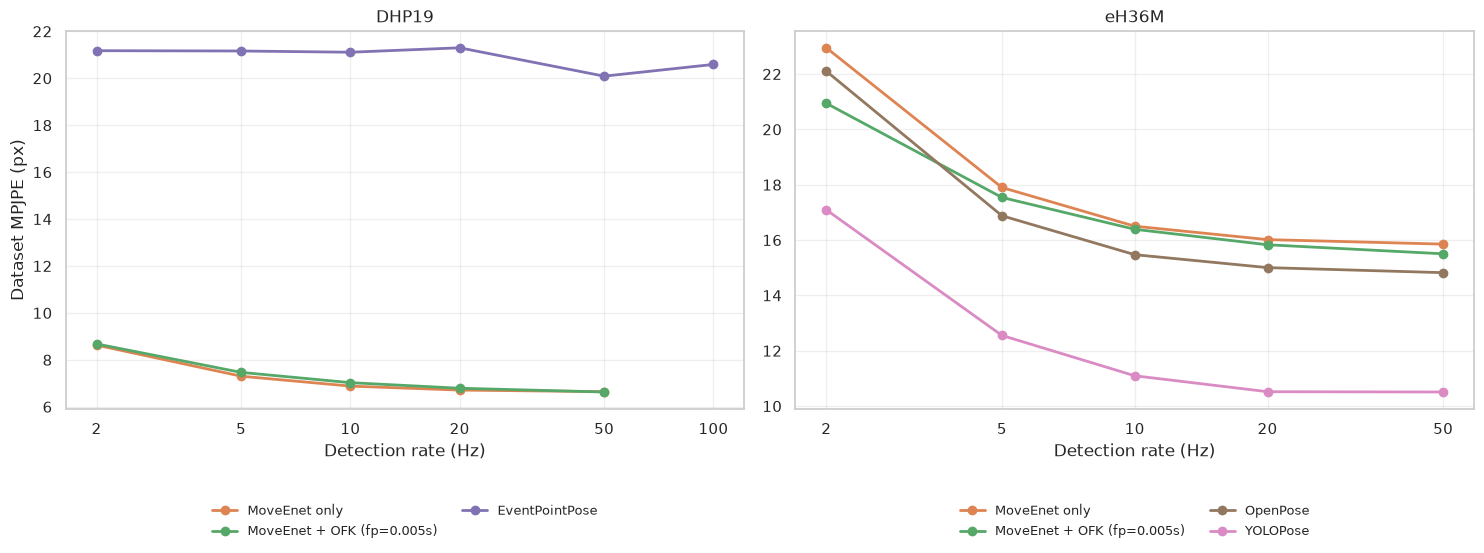

Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/plots/mpjpe_vs_detection_rate_by_method.png


In [47]:
plot_metric(
    table=df_table,
    metric='mpjpe_px',
    ylabel='Dataset MPJPE (px)',
    x_col='detection_rate_hz',
    xlabel='Detection rate (Hz)',
    output_name='mpjpe_vs_detection_rate_by_method.png',
)


## PCK@0.2 and PCK@0.4 comparison


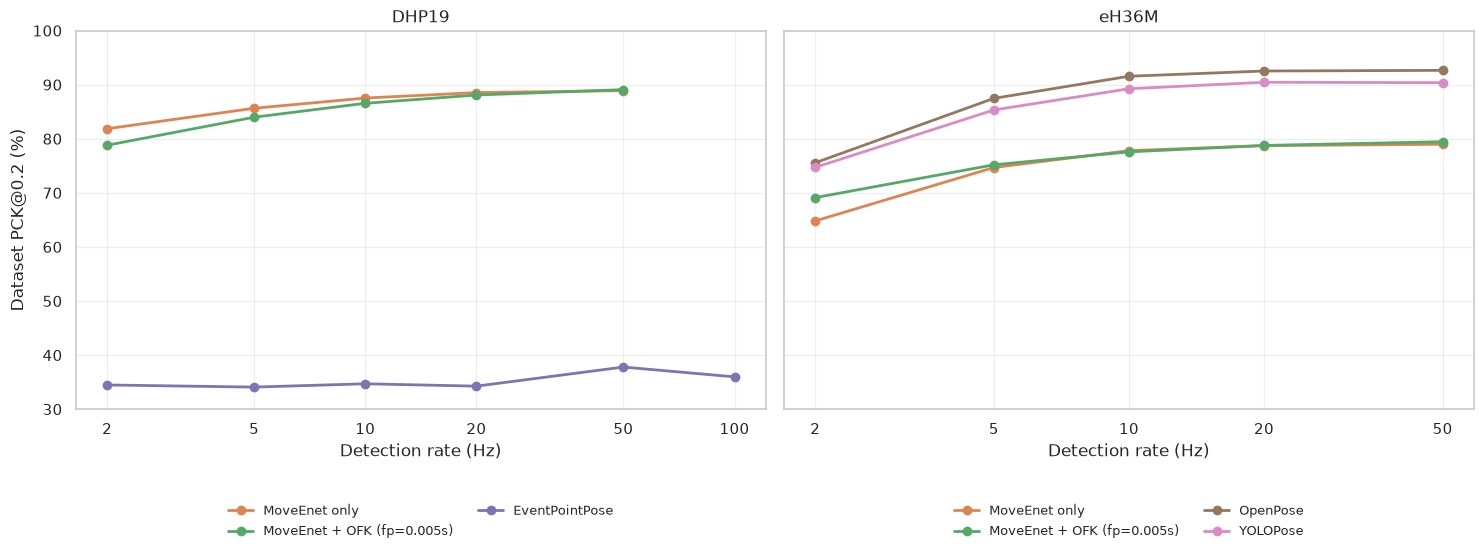

Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/plots/pck_0.2_vs_detection_rate_by_method.png


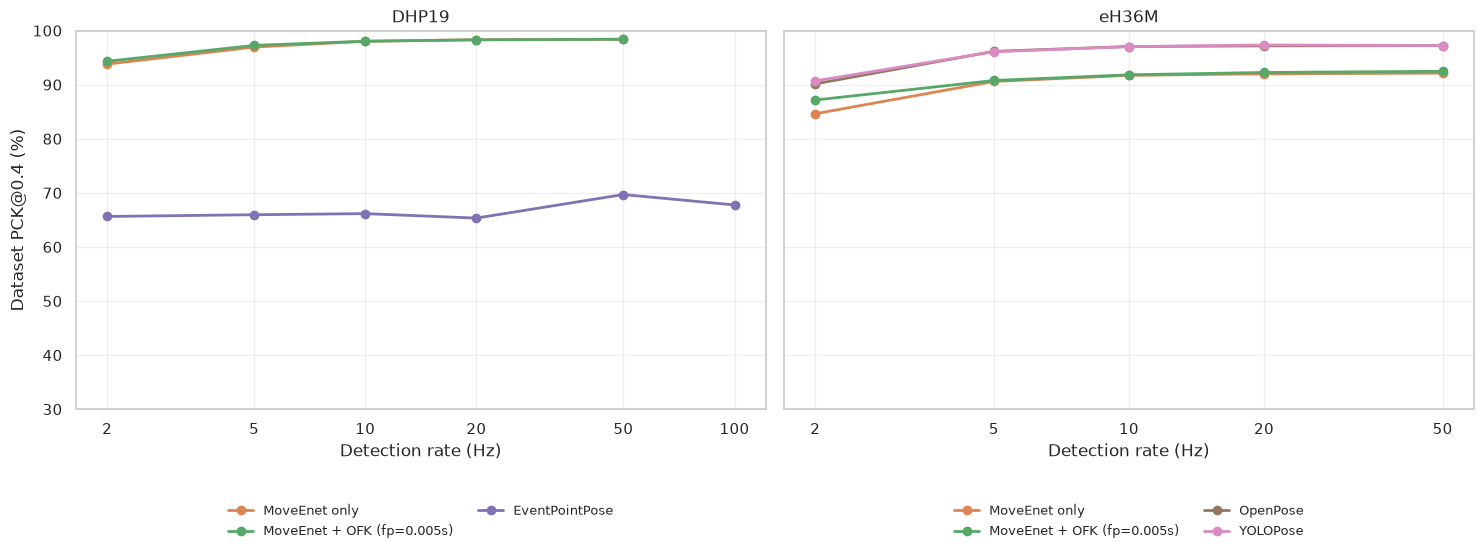

Saved: /home/dberretta-iit.local/data/moveEnetOFK/Comparison/selected_runs/dhp19-eh36m__moveenet-only__moveenet-ofk__yolopose__openpose__eventpointpose/plots/pck_0.4_vs_detection_rate_by_method.png


In [48]:
for th in PCK_THRESHOLDS:
    pck_col = f'pck_{th:.1f}'

    plot_metric(
        table=df_table,
        metric=pck_col,
        ylabel=f'Dataset PCK@{th:.1f} (%)',
        x_col='detection_rate_hz',
        xlabel='Detection rate (Hz)',
        output_name=f'pck_{th:.1f}_vs_detection_rate_by_method.png',
        ylim=(30, 100),
    )


## Compact summary views


In [49]:
summary_display = df_table[compact_cols].copy()
summary_display['mpjpe_px'] = summary_display['mpjpe_px'].round(3)
for col in pck_cols:
    summary_display[col] = summary_display[col].round(3)

display(summary_display)

best_mpjpe = (
    df_table
    .sort_values('mpjpe_px')
    .groupby(['dataset', 'network_period_s'], as_index=False)
    .head(1)
    [['dataset', 'network_period_s', 'detection_rate_hz', 'method_variant', 'mpjpe_px']]
    .sort_values(['dataset', 'network_period_s'])
)
print('Lowest MPJPE for each dataset/network period:')
display(best_mpjpe)

for col in pck_cols:
    best_pck = (
        df_table
        .sort_values(col, ascending=False)
        .groupby(['dataset', 'network_period_s'], as_index=False)
        .head(1)
        [['dataset', 'network_period_s', 'detection_rate_hz', 'method_variant', col]]
        .sort_values(['dataset', 'network_period_s'])
    )
    print(f'Highest {col.upper()} for each dataset/network period:')
    display(best_pck)


,dataset,network_period_s,detection_rate_hz,method_variant,n_sequences,n_samples,n_points,mpjpe_px,pck_0.2,pck_0.4
0,dhp19,0.01,100.0,EventPointPose,79,355423,4620499,20.589,35.981,67.764
1,dhp19,0.02,50.0,EventPointPose,69,304421,3957473,20.089,37.792,69.689
2,dhp19,0.02,50.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,6.631,89.086,98.396
3,dhp19,0.02,50.0,MoveEnet only,79,277751,3610763,6.644,88.899,98.399
4,dhp19,0.05,20.0,EventPointPose,79,355099,4616287,21.297,34.262,65.334
5,dhp19,0.05,20.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,6.790,88.089,98.293
6,dhp19,0.05,20.0,MoveEnet only,79,277751,3610763,6.712,88.541,98.310
7,dhp19,0.10,10.0,EventPointPose,79,354711,4611243,21.109,34.700,66.159
8,dhp19,0.10,10.0,MoveEnet + OFK (fp=0.005s),79,277751,3610763,7.028,86.560,98.034
9,dhp19,0.10,10.0,MoveEnet only,79,277751,3610763,6.881,87.528,98.025


Lowest MPJPE for each dataset/network period:


,dataset,network_period_s,detection_rate_hz,method_variant,mpjpe_px
0,dhp19,0.01,100.0,EventPointPose,20.589045
2,dhp19,0.02,50.0,MoveEnet + OFK (fp=0.005s),6.630619
6,dhp19,0.05,20.0,MoveEnet only,6.711935
9,dhp19,0.10,10.0,MoveEnet only,6.881212
12,dhp19,0.20,5.0,MoveEnet only,7.304019
15,dhp19,0.50,2.0,MoveEnet only,8.628659
19,eh36m,0.02,50.0,YOLOPose,10.509684
23,eh36m,0.05,20.0,YOLOPose,10.519898
27,eh36m,0.10,10.0,YOLOPose,11.095828
31,eh36m,0.20,5.0,YOLOPose,12.553709


Highest PCK_0.2 for each dataset/network period:


,dataset,network_period_s,detection_rate_hz,method_variant,pck_0.2
0,dhp19,0.01,100.0,EventPointPose,35.981352
2,dhp19,0.02,50.0,MoveEnet + OFK (fp=0.005s),89.085936
6,dhp19,0.05,20.0,MoveEnet only,88.541065
9,dhp19,0.10,10.0,MoveEnet only,87.528259
12,dhp19,0.20,5.0,MoveEnet only,85.642314
15,dhp19,0.50,2.0,MoveEnet only,81.856494
18,eh36m,0.02,50.0,OpenPose,92.647723
22,eh36m,0.05,20.0,OpenPose,92.530481
26,eh36m,0.10,10.0,OpenPose,91.556826
30,eh36m,0.20,5.0,OpenPose,87.470967


Highest PCK_0.4 for each dataset/network period:


,dataset,network_period_s,detection_rate_hz,method_variant,pck_0.4
0,dhp19,0.01,100.0,EventPointPose,67.764499
3,dhp19,0.02,50.0,MoveEnet only,98.399258
6,dhp19,0.05,20.0,MoveEnet only,98.310274
8,dhp19,0.10,10.0,MoveEnet + OFK (fp=0.005s),98.033878
11,dhp19,0.20,5.0,MoveEnet + OFK (fp=0.005s),97.261244
14,dhp19,0.50,2.0,MoveEnet + OFK (fp=0.005s),94.327487
19,eh36m,0.02,50.0,YOLOPose,97.228597
23,eh36m,0.05,20.0,YOLOPose,97.341407
26,eh36m,0.10,10.0,OpenPose,97.056447
30,eh36m,0.20,5.0,OpenPose,96.161337
